# BTSP on a linear track (1-compartment neurons)

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent set to travel in one direction along the track, reseting at the end.
* Pyramidal neuron layer:
  * Input from uniformly distributed Gaussian place cells (plastic)
  * 1 or multiple pyramidal neurons
* Learning:
  * BTSP learning: strong learning with a broad kernel, induced externally or occurring when a neuron's activation passes a predetermined threshold.
  * Hebbian learning (optional)

In [1]:
import importlib
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import agent, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import learn_util, plot_util, params_util, ext_util, hyper_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "linear_track_1comp"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## BTSP kernel

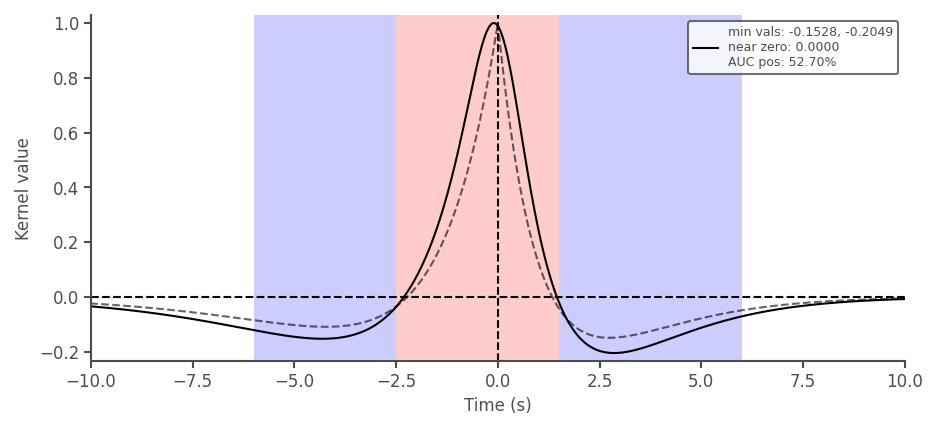

In [5]:
dt = params_util.DT
sigma_in_steps = ext_util.get_sigma_in_steps(sigma=params_util.PC_SIGMA, dt=dt)
filter_param_dict = params_util.get_default_BTSP_filter_param_dict(incl_BTSP_str=False)

plot_util.plot_summed_exp_kernel(
    dt=dt,
    sigma_in_steps=sigma_in_steps,
    plot_unsmoothed=True,
    target_root_dict=hyper_util.get_target_root_dict(),
    **filter_param_dict
);

## 1. Only 1 Pyr. neuron
BTSP induced externally at target location (after the 4th encounter).  
Hebbian learning is disabled.

In [8]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 10000

USE_HEBBIAN = False

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=params_util.SCALE_LINEAR / 2,
    wait_at_end=0,
)

Pyr_params_one = params_util.get_Pyr_params(
    n=1, environment="linear", 
    two_compartment=False, 
    BTSP=True, 
    NMDA=False,
    normalize_weights_divisively=USE_HEBBIAN,
    BTSP_lr=0.5,
    log_BTSP=True
)

 22%|███████▊                            | 2179/10000 [00:01<00:04, 1643.36it/s]

BTSP event recorded for neuron 0 at step 2008 (60.24 sec).


 30%|██████████▊                         | 3001/10000 [00:01<00:04, 1635.55it/s]

BTSP update applied to neuron 0 at step 2702 (81.06 sec).


 61%|█████████████████████▉              | 6094/10000 [00:03<00:02, 1556.61it/s]


Finishing last trajectory.


367it [00:00, 2164.30it/s]


Reached target 8 times.
Trajectory lengths (9) to date: 21.54 +/- 7.62 sec each
Trajectory lengths (9) to date: 718.11 +/- 254.16 steps each
1 BTSP events triggered (allowed from steps 1588 to 6462): occurred at step 2008.


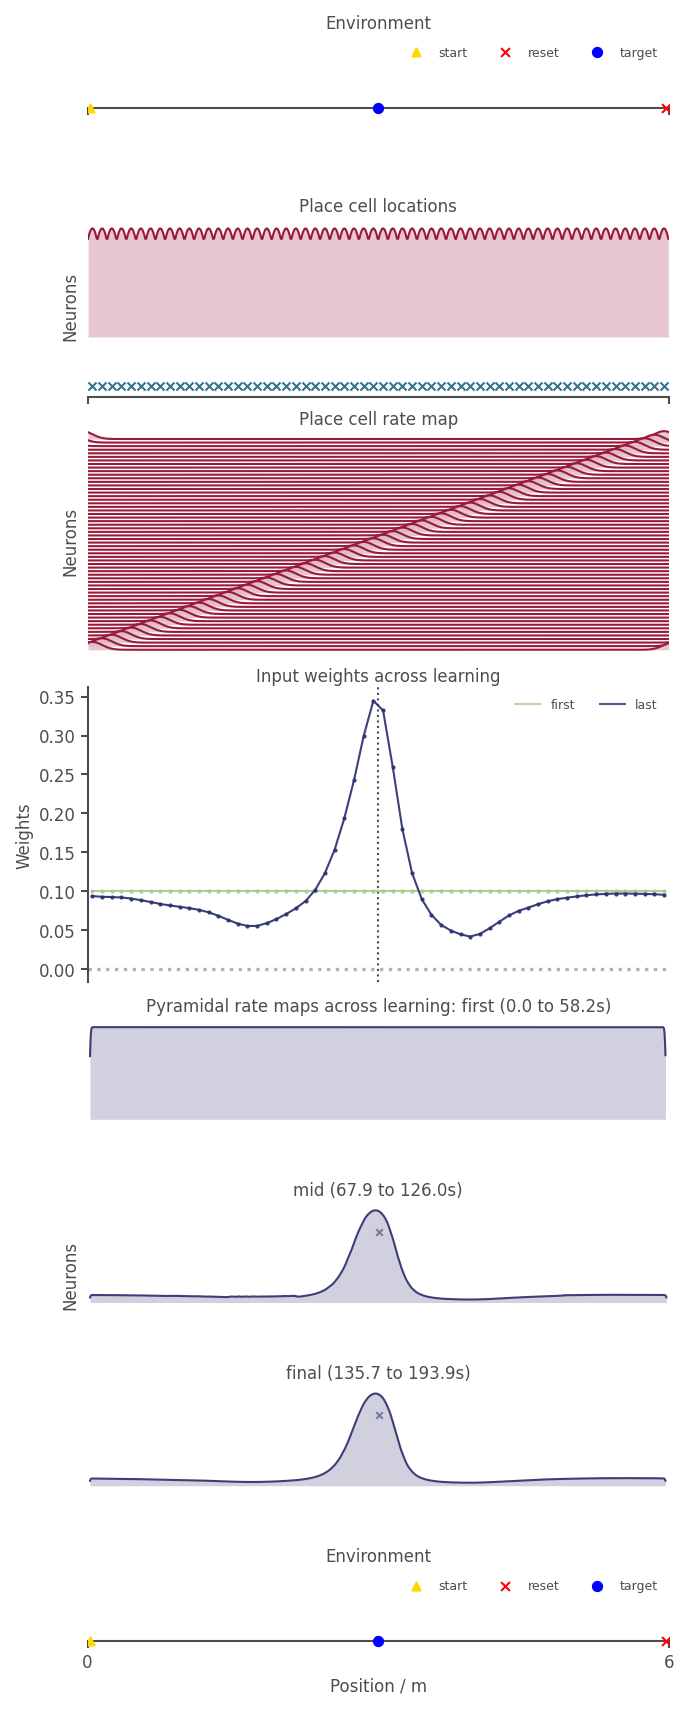

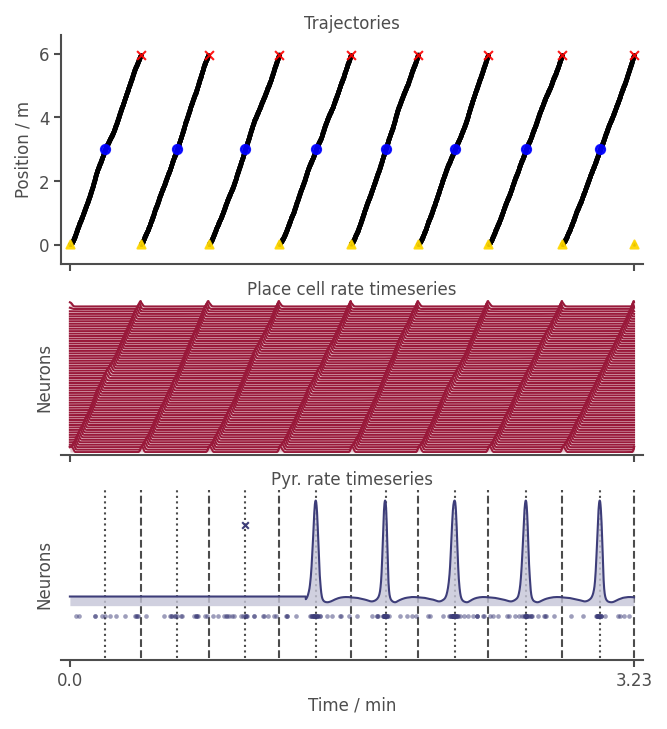

In [9]:
learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
    agent_params=agent_params,
    Pyr_params=Pyr_params_one,
    num_target_reaches=NUM_REWARDS,
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=3,
)

ALL_FIGURES["1-single_spatial"] = spatial_axes
ALL_FIGURES["1-single_time"] = time_axes

Speed mean: 24.00 cm/s, std: 4.41 cm/s.


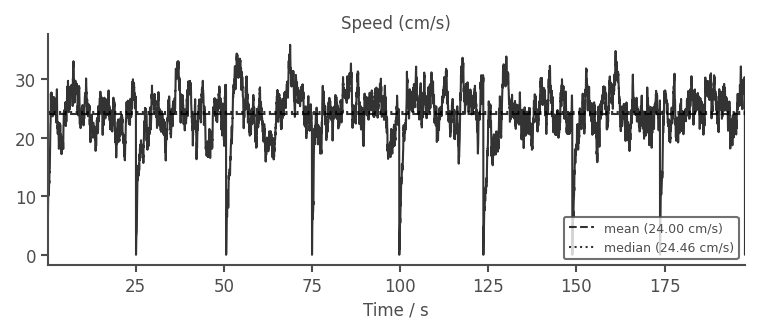

In [7]:
learner.Agent.log_speed_stats()
sub_ax = learner.Agent.plot_speed(mark_median=True, mark_mean=True)

ALL_FIGURES["1-single_speed"] = sub_ax

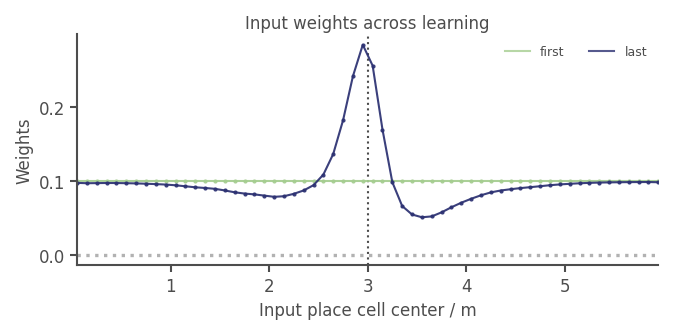

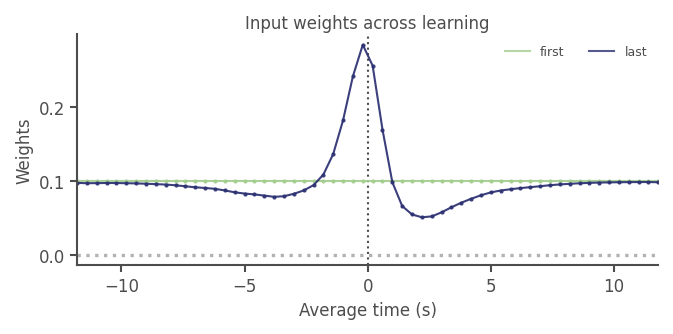

In [8]:
ws = [learner.Pyrs.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["1-single_weights"] = sub_ax
ALL_FIGURES["1-single_weights_time"] = sub_ax_time

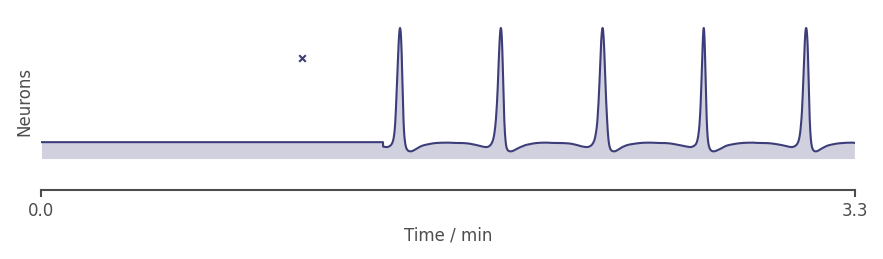

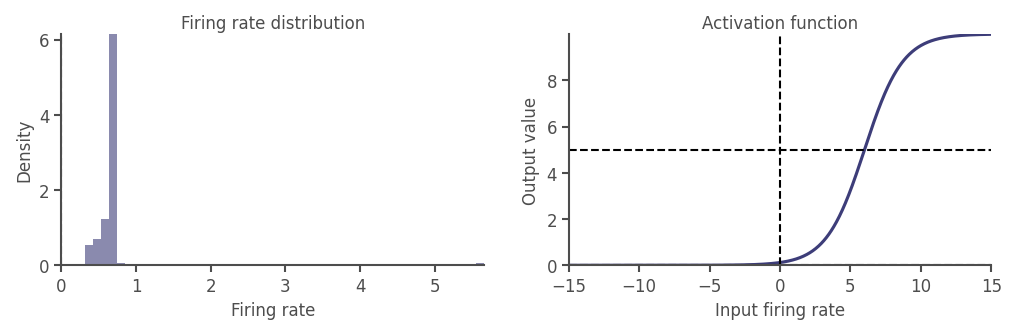

In [9]:
fig, sub_ax = plt.subplots(figsize=(7, 1.5))
learner.Pyrs.plot_rate_timeseries(sub_ax=sub_ax)

fig, ax1D = plt.subplots(1, 2, figsize=(8, 2))
learner.Pyrs.plot_firingrate_distribution(sub_ax=ax1D[0]);
learner.Pyrs.plot_activation_function(sub_ax=ax1D[1]);
ALL_FIGURES["1-firingrate"] = sub_ax
ALL_FIGURES["1-firingrates_activation"] = ax1D

### BTSP filters

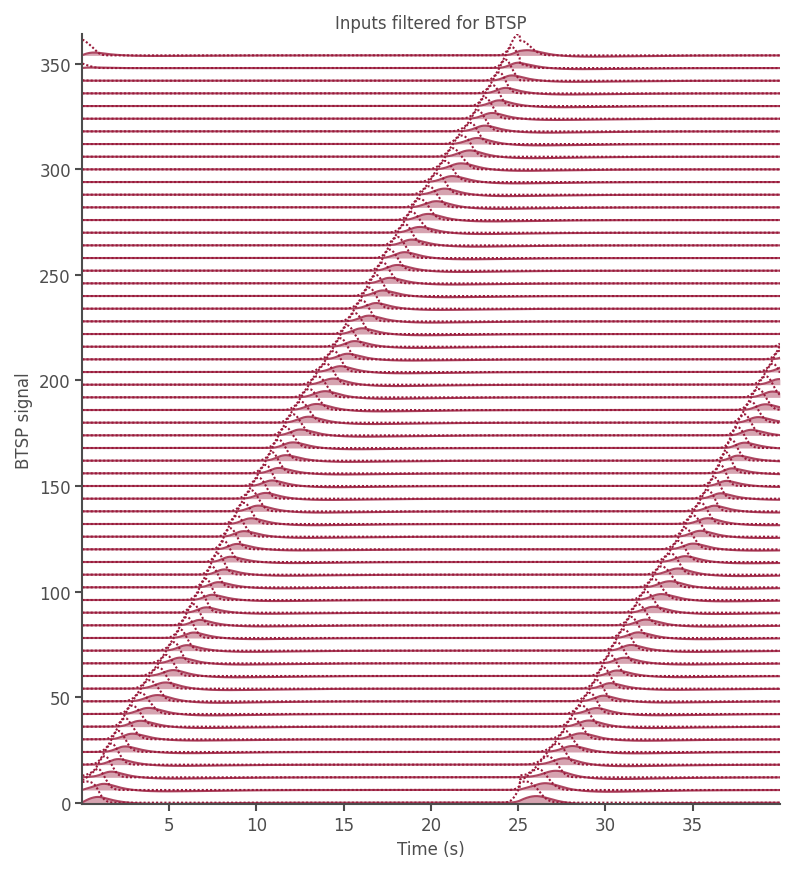

In [10]:
sub_ax = learner.Pyrs.plot_filtered_for_BTSP("PCs", t_end=40)
ALL_FIGURES["1-single_pre_BTSP_filter"] = sub_ax

BTSP events applied after 657.00 steps (19.71 sec.) (num steps: 657).


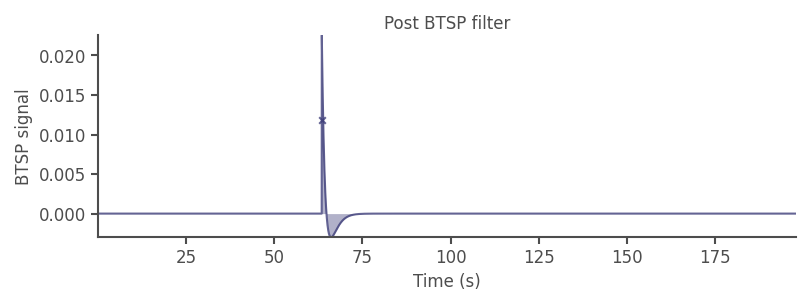

In [11]:
learner.Pyrs.log_num_steps_to_apply_BTSP()
sub_ax = learner.Pyrs.plot_filtered_for_BTSP()
ALL_FIGURES["1-single_post_BTSP_filter"] = sub_ax

## 2. Multiple Pyr. neurons
BTSP induced externally at for two neurons: (1) at the target location, and (2) at the start location (in each case, after the 3rd encounter).  
Hebbian learning is enabled (**much** weaker than BTSP).

In [12]:
%autoreload 2

In [13]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 10000

USE_HEBBIAN = True

INIT_WEIGHTS_ZERO = False
W_INIT_SCALE = 0.2

Pyr_params_mult = params_util.get_Pyr_params(
    n=4, environment="linear", 
    two_compartment=False, 
    BTSP=True, 
    NMDA=False,
    init_weights_zero=INIT_WEIGHTS_ZERO,
    w_init_scale=W_INIT_SCALE,
    normalize_weights_divisively=USE_HEBBIAN,
    log_BTSP=True,
)

 19%|██████▋                             | 1864/10000 [00:01<00:05, 1530.53it/s]

BTSP event recorded for neuron 3 at step 1692 (50.76 sec).


 23%|████████▎                           | 2321/10000 [00:01<00:05, 1504.94it/s]

BTSP event recorded for neuron 0 at step 2112 (63.36 sec).
BTSP update applied to neuron 3 at step 2347 (70.41 sec).


 31%|███████████                         | 3068/10000 [00:02<00:05, 1288.07it/s]

BTSP update applied to neuron 0 at step 2767 (83.01 sec).


100%|███████████████████████████████████| 10000/10000 [00:07<00:00, 1419.40it/s]


Finishing last trajectory.


568it [00:00, 1520.36it/s]


Only reached target 13 times (target: 16).
Trajectory lengths (14) to date: 22.65 +/- 6.31 sec each
Trajectory lengths (14) to date: 754.93 +/- 210.22 steps each
2 BTSP events triggered (allowed from steps 1690 to 10568): occurred between steps 1692 and 2112, inclusively.


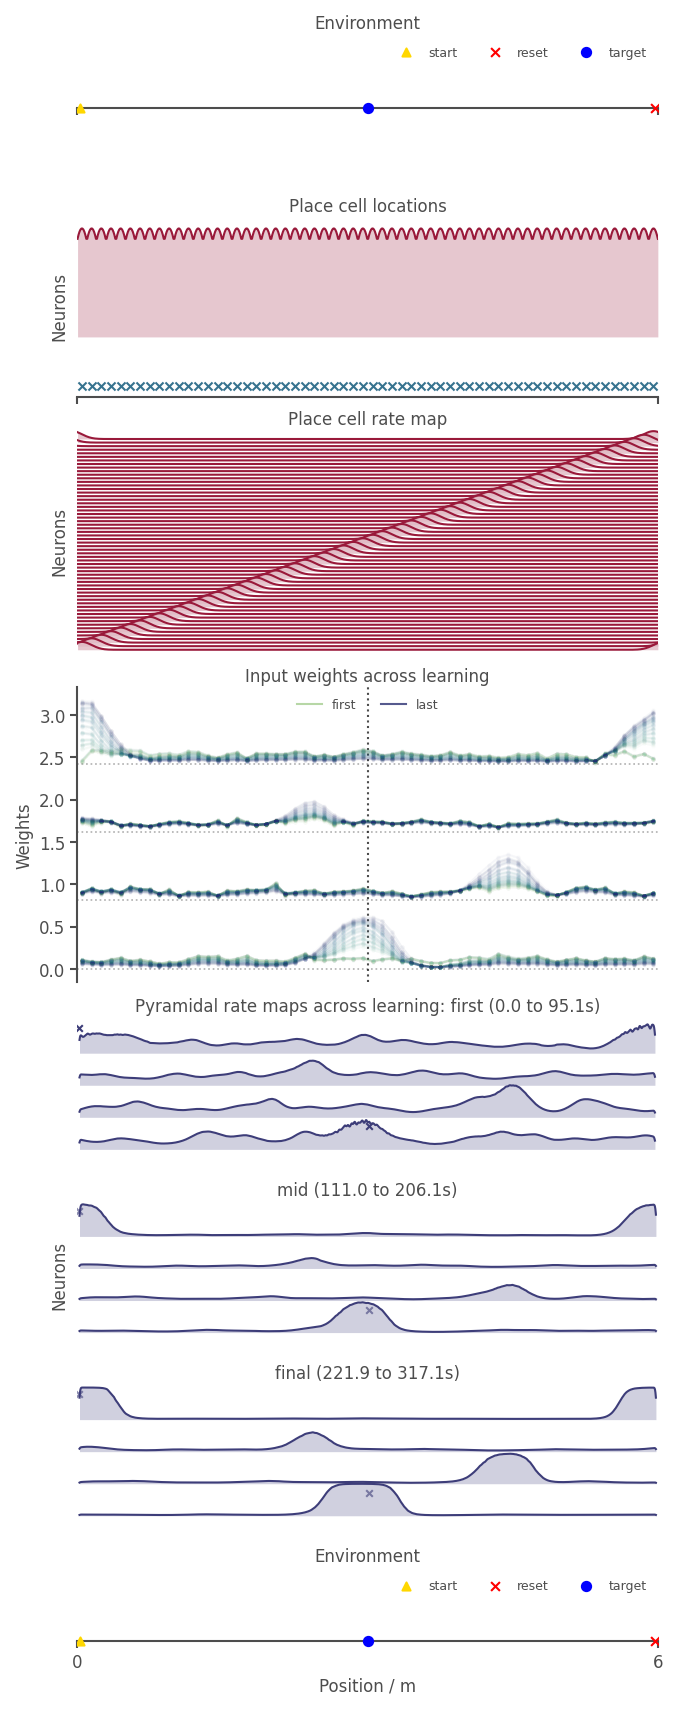

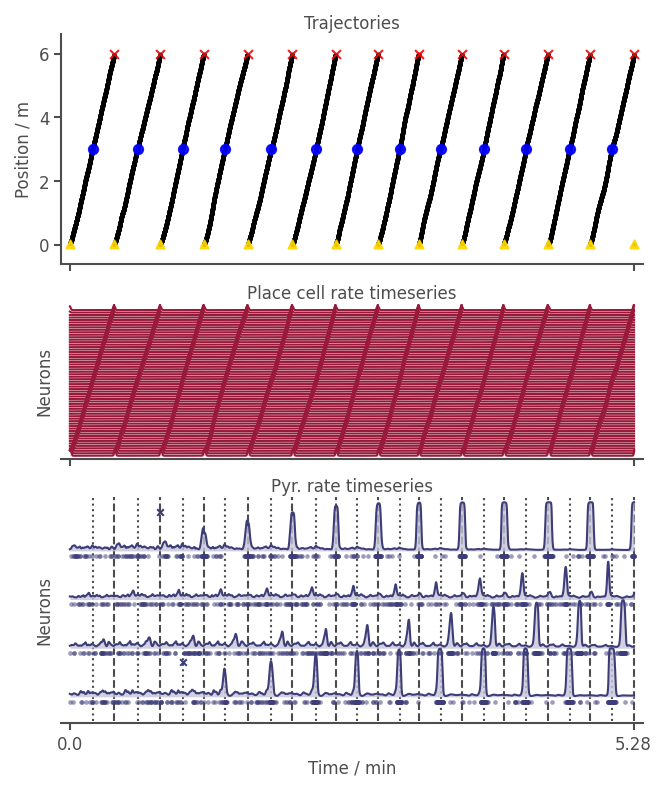

In [14]:
learner_mult, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
        agent_params=agent_params,
        Pyr_params=Pyr_params_mult,
        num_target_reaches=NUM_REWARDS,
        max_num_steps=MAX_NUM_STEPS,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=3,
    )

ALL_FIGURES["2-multiple_spatial"] = spatial_axes
ALL_FIGURES["2-multiple_time"] = time_axes

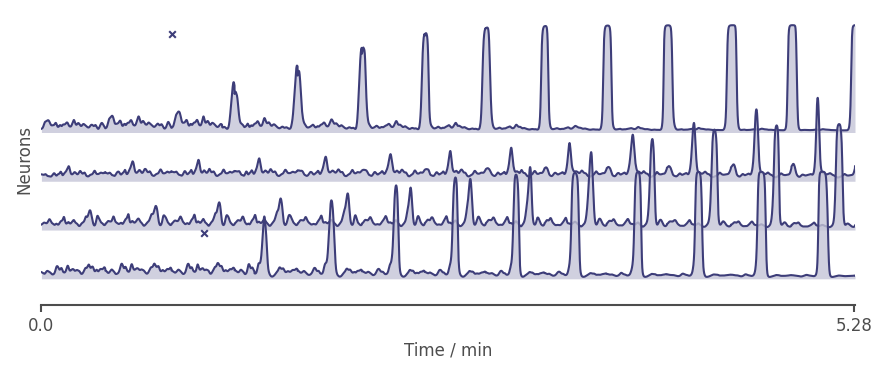

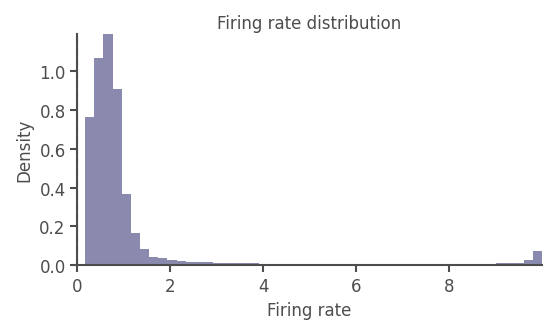

In [15]:
fig, sub_ax = plt.subplots(figsize=(7, 2.5))
learner_mult.Pyrs.plot_rate_timeseries(sub_ax=sub_ax)
sub_ax_hist = learner_mult.Pyrs.plot_firingrate_distribution()
ALL_FIGURES["1-firingrate"] = sub_ax
ALL_FIGURES["1-firingrate_hist"] = sub_ax_hist

### BTSP filters

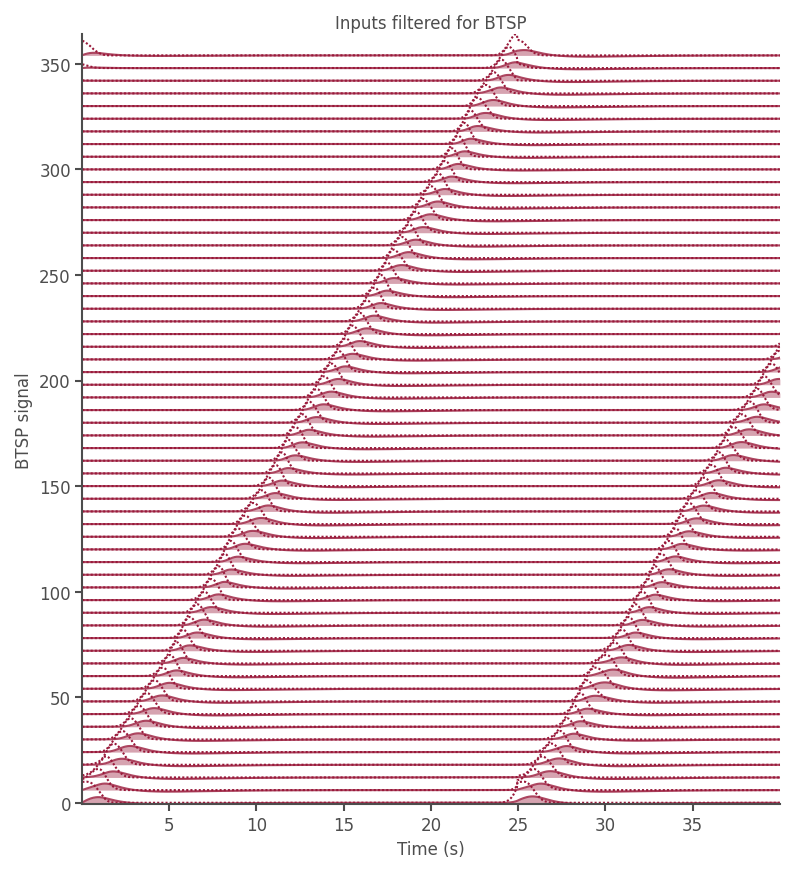

In [16]:
learner_mult.Pyrs.plot_filtered_for_BTSP("PCs", t_start=0, t_end=40)
ALL_FIGURES["2-multiple_pre_BTSP_filter"] = sub_ax

BTSP events applied after 657.00 steps (19.71 sec.) (num steps: 657, 657).


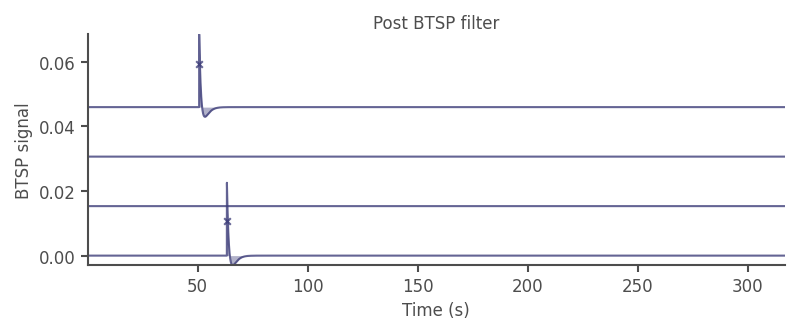

In [17]:
learner_mult.Pyrs.log_num_steps_to_apply_BTSP()
sub_ax = learner_mult.Pyrs.plot_filtered_for_BTSP()
ALL_FIGURES["2-multiple_post_BTSP_filter"] = sub_ax

## 3. Internally-generated BTSP
BTSP occurs the first time a neuron achieves a specific activity threshold.  
Hebbian learning is enabled, allowing threshold to eventually be reached.  
**Note:** Target position is irrelevant as it does not affect neural activity.

In [18]:
%autoreload 2

In [19]:
MAX_NUM_STEPS = 10000 # many steps

USE_HEBBIAN = True

INIT_WEIGHTS_ZERO = False
W_INIT_SCALE = 0.2
SINGLE_BTSP = True

Pyr_params_internal = params_util.get_Pyr_params(
    n=1, environment="linear", 
    two_compartment=False, 
    BTSP=True,
    NMDA=True,
    init_weights_zero=INIT_WEIGHTS_ZERO,
    w_init_scale=W_INIT_SCALE,
    normalize_weights_divisively=USE_HEBBIAN,
    single_BTSP=SINGLE_BTSP,
    log_BTSP=True,
)

 92%|█████████████████████████████████▎  | 9245/10000 [00:07<00:00, 1330.83it/s]

BTSP event recorded for neuron 0 at step 8998 (269.94 sec).


 99%|███████████████████████████████████▋| 9912/10000 [00:07<00:00, 1329.09it/s]

BTSP update applied to neuron 0 at step 9653 (289.59 sec).


100%|███████████████████████████████████| 10000/10000 [00:07<00:00, 1271.05it/s]


Finishing last trajectory.


545it [00:00, 1340.84it/s]


Only reached target 13 times (target: 16).
Trajectory lengths (14) to date: 22.60 +/- 6.29 sec each
Trajectory lengths (14) to date: 753.29 +/- 209.70 steps each
1 BTSP events triggered (allowed from steps 0 to 10545): occurred at step 8998.


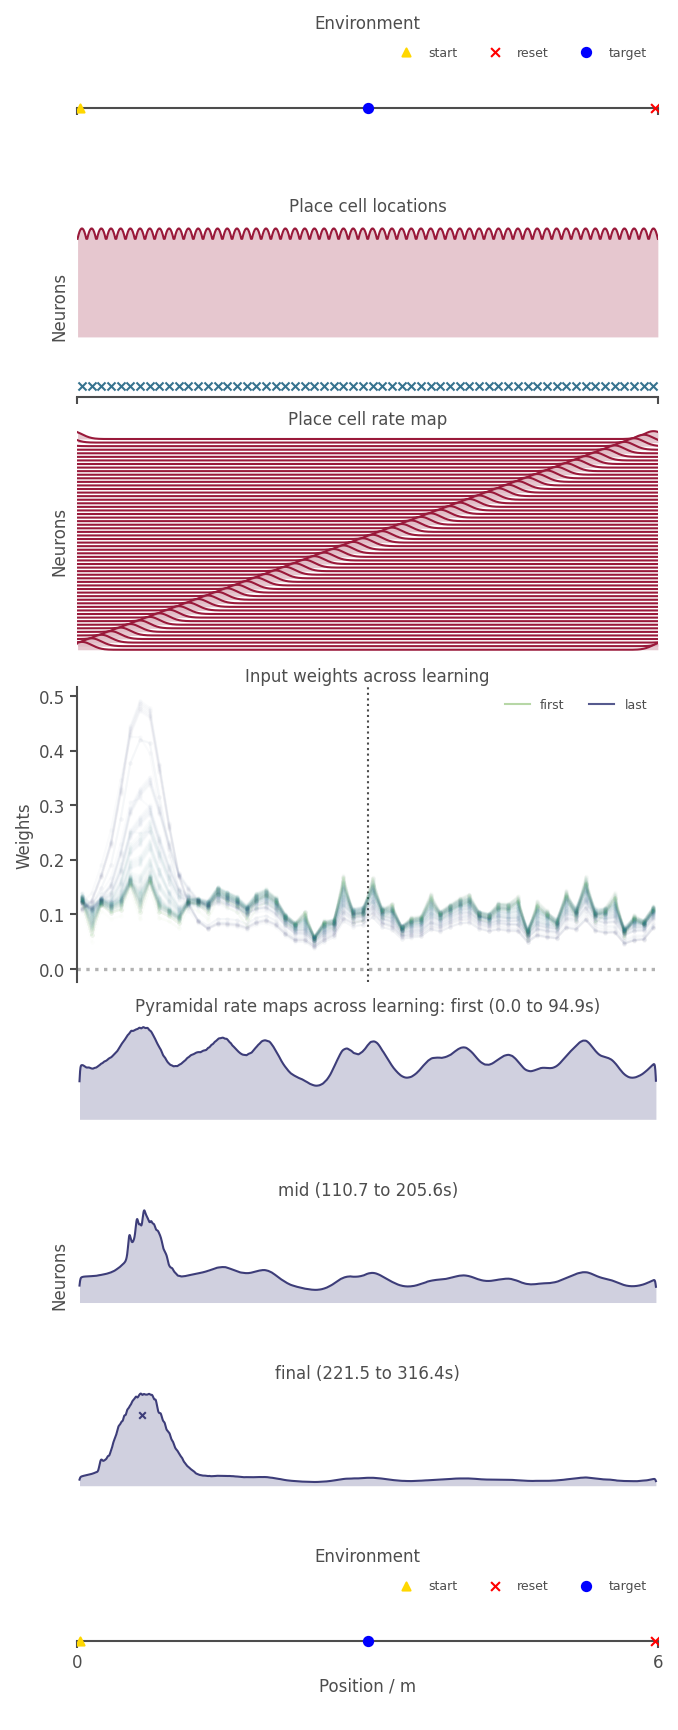

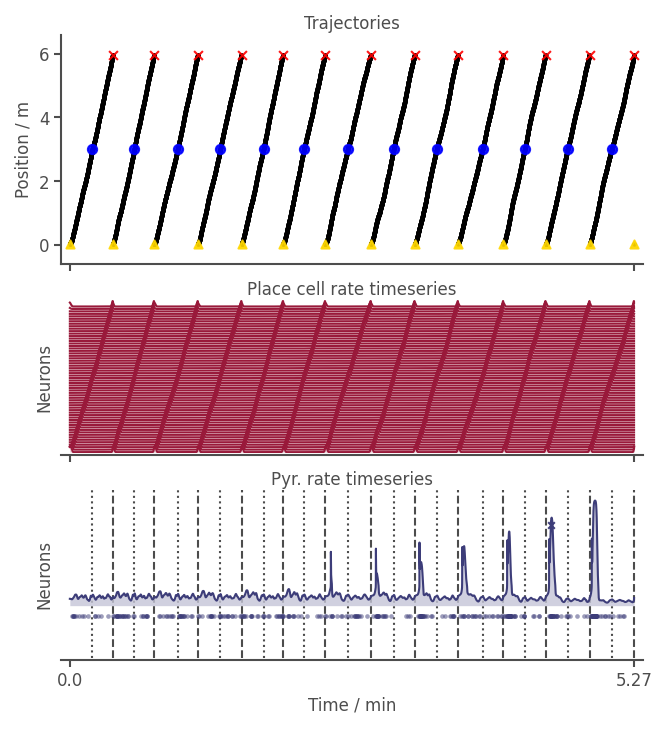

In [20]:
learner_internal, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
        agent_params=agent_params,
        Pyr_params=Pyr_params_internal,
        num_target_reaches=NUM_REWARDS,
        max_num_steps=MAX_NUM_STEPS,
        use_Hebbian=USE_HEBBIAN,
    )

ALL_FIGURES["3-internal_spatial"] = spatial_axes
ALL_FIGURES["3-internal_time"] = time_axes

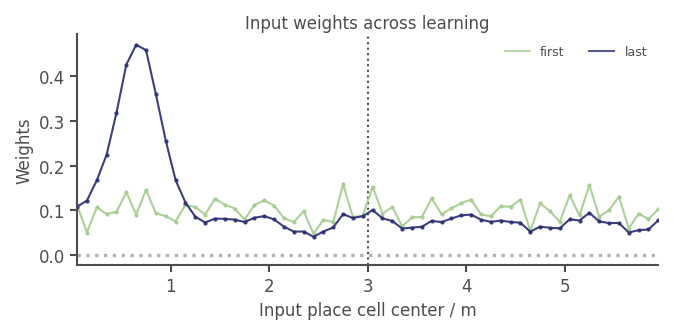

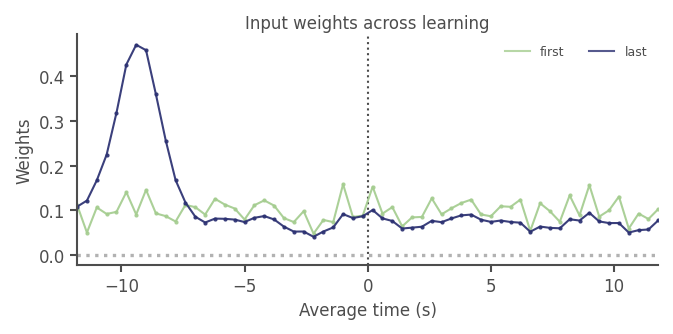

In [21]:
ws = [learner_internal.Pyrs.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_internal.Pyrs.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_internal.Pyrs.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["3-internal_weights"] = sub_ax
ALL_FIGURES["3-internal_weights_time"] = sub_ax_time

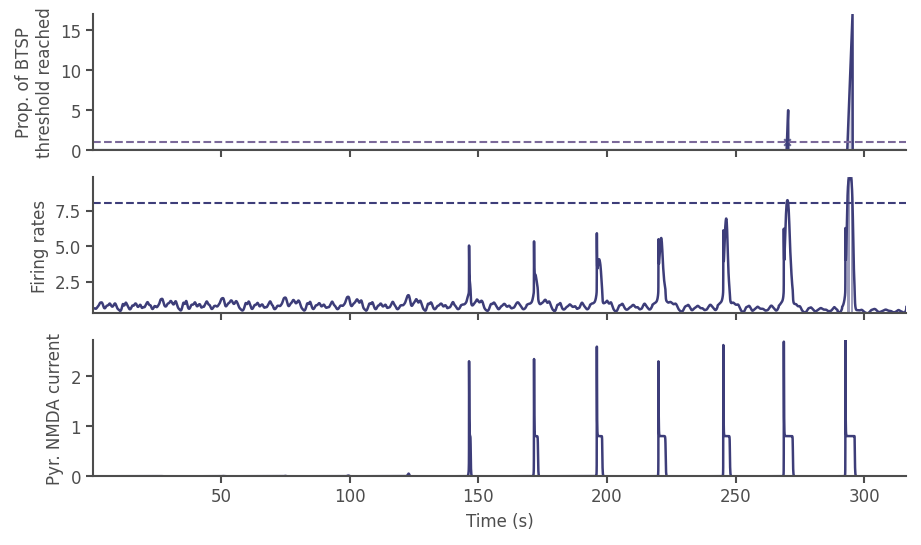

In [22]:
ax1D = learner_internal.Pyrs.plot_BTSP_ramp()

ALL_FIGURES["3-internal_BTSP_timeseries"] = ax1D

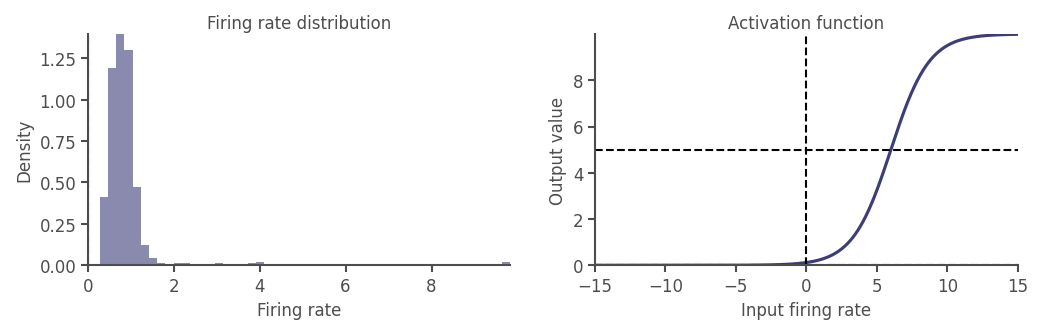

In [23]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 2))
sub_ax = learner_internal.Pyrs.plot_firingrate_distribution(sub_ax=ax1D[0])
sub_ax = learner_internal.Pyrs.plot_activation_function(sub_ax=ax1D[1])

ALL_FIGURES["3-internal_firingrates_activation"] = ax1D

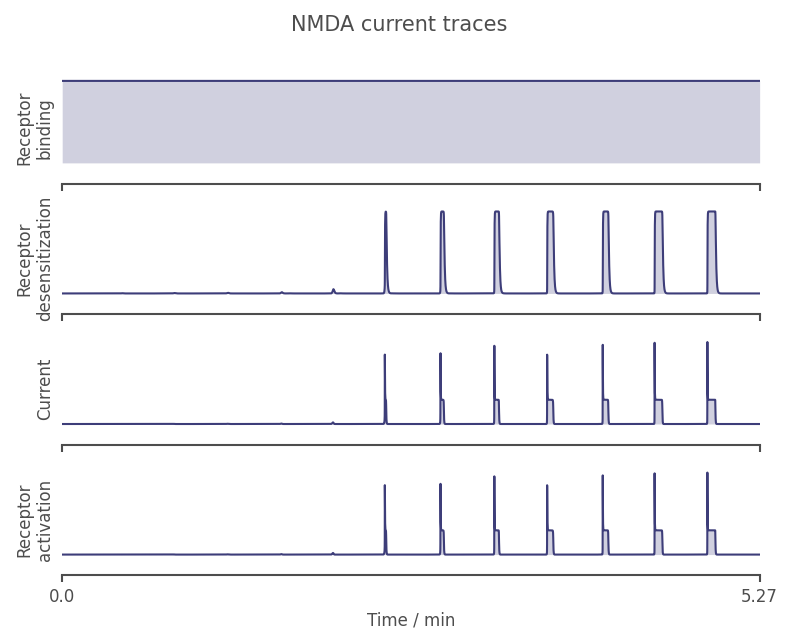

In [24]:
ax1D = learner_internal.Pyrs.NMDACurrent.plot_timeseries(datatypes="all")

ALL_FIGURES["3-internal_NMDA_current"] = ax1D

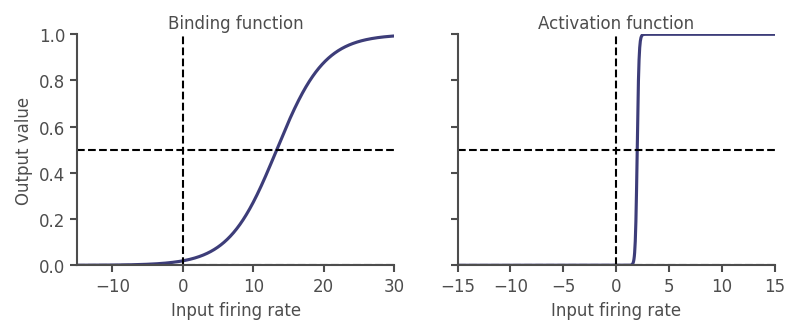

In [25]:
fig, ax1D = plt.subplots(1, 2, figsize=[6, 2], sharey=True)
learner_internal.Pyrs.NMDACurrent.plot_function("binding", max_input_fr=30, sub_ax=ax1D[0])
learner_internal.Pyrs.NMDACurrent.plot_function("activation", min_input_fr=-15, max_input_fr=15, sub_ax=ax1D[1])
ax1D[1].set_ylabel("")

ALL_FIGURES["3-internal_NMDA_functions"] = ax1D

## 4. Save

In [26]:
SAVE = True

In [27]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 22 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_spatial_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_time_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_speed_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_weights_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_weights_time_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-firingrate_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-firingrates_activation_1702.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track_1comp/25_04_30/1-single_pre_BTSP